## Table of Contents

- [Examining aperture photometry results and SNR for different sizes](#Examining-aperture-photometry-results-and-SNR-for-different-sizes)
  - [r=13 data](#r=13-data)
  - [r=8 data](#r=8-data)
  - [r=5 data](#r=5-data)
  - [SNR comparison between apertures](#SNR-comparison-between-apertures)
- [Looking at quality of subtractions](#Looking-at-quality-of-subtractions)
- [Investigate SNR and mag scatter as a function of time](#Investigate-SNR-and-mag-scatter-as-a-function-of-time)
  - [SNR over time](#SNR-over-time)
  - [SNR vs airmass](#SNR-vs-airmass)
- [Zeropoint cross checks](#Zeropoint-cross-checks)
- [Source Extractor Flagging](#Source-Extractor-Flagging)
- [Examining Bad Subtractions](#Examining-Bad-Subtractions)

In [2]:
import math
import os
import sys

project_root = os.path.expanduser('~/git/neoexchange-devel/neoexchange')
sys.path.insert(0, project_root)
# Original line
# didymos_data = os.path.expanduser("~/git/Didymos_data")
didymos_data = os.path.join(os.sep, "apophis", "tlister", "didymos_data", "Hera_Didymos_data")
didymos_photometry = os.path.join(didymos_data, "didymos_photometry")

os.environ.setdefault('DJANGO_SETTINGS_MODULE', 'neox.settings')
os.environ.setdefault('DJANGO_ALLOW_ASYNC_UNSAFE', 'true')

import django

django.setup()

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
from astropy import units as u
from astropy.coordinates import AltAz, EarthLocation, SkyCoord
from astropy.io import fits
from astropy.table import Table, join
from astropy.time import Time
from matplotlib.patches import Rectangle
from matplotlib.ticker import AutoMinorLocator

os.chdir(project_root) #temp fix for json issue
#from core.views import GuideMovie
#from core.plots import generalized_fwhm_plotter, generalized_zeropoint_plotter  #get pngs for fwhm and zp to analyze
from core.management.commands.lightcurve_extraction import Command
from core.models import Block, Frame, StaticSource
from core.views import examine_subtractions
from photometrics.gf_movie import make_gif

# Select the plotting backend AFTER the NEOexchange imports above:
# photometrics/SA_scatter.py and photometrics/obsgeomplot.py both call
# matplotlib.use('Agg') at import time (pulled in via core.views), which
# overrides any backend chosen earlier and silently discards every plot.
%matplotlib inline

In [4]:
# The aper_p_*.ecsv photometry tables were written by the original author with
# their own paths ("/home/mwalker/git/Didymos_data/...") baked into the
# "path to frame" column. Remap those onto didymos_data in memory after each
# Table.read(); the .ecsv files on disk are left untouched.
ORIG_DATA_ROOT = os.path.join(os.sep, "home", "mwalker", "git", "Didymos_data")


def remap_frame_paths(table, column="path to frame", old_root=ORIG_DATA_ROOT, new_root=None):
    """Repoint <column> of <table> at the local copy of the data, in memory.

    Rows whose path does not start with <old_root> are left alone, so calling
    this twice (or on an already-local table) is harmless. Returns the table.
    """

    new_root = new_root or didymos_data
    if column not in table.colnames:
        print(f"remap_frame_paths: no {column!r} column, nothing to do")
        return table

    old_paths = [str(path) for path in table[column]]
    new_paths = [os.path.join(new_root, os.path.relpath(path, old_root))
                 if path.startswith(old_root) else path
                 for path in old_paths]
    table[column] = new_paths

    n_remapped = sum(old != new for old, new in zip(old_paths, new_paths))
    missing = [path for path in new_paths if not os.path.exists(path)]
    print(f"remap_frame_paths: {n_remapped} of {len(new_paths)} rows remapped onto "
          f"{new_root}; {len(missing)} file(s) missing on disk")
    if missing:
        print(f"  e.g. {missing[0]}")
    return table


In [29]:
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales

frames = Frame.objects.filter(
    block_id=35906,
    frametype=Frame.NEOX_RED_FRAMETYPE,
    filter="rp",
    rms_of_fit__gt=0,
)

pixel_scales = []
missing_files = []
unusable_wcs = []
for frame in frames:
    try:
        wcs = frame.wcs
        if wcs is None:
            unusable_wcs.append(frame.filename)
            continue

        axis_scales = proj_plane_pixel_scales(wcs.celestial) * 3600  # arcsec/pixel
        scale = np.mean(axis_scales)

        if np.isfinite(scale):
            pixel_scales.append(scale)
        else:
            unusable_wcs.append(frame.filename)
    except (AttributeError, TypeError, ValueError):
        unusable_wcs.append(frame.filename)

if pixel_scales:
    print(f"Frames with usable WCS: {len(pixel_scales)}")
    pixel_scale = np.mean(pixel_scales) * (u.arcsec / u.pixel)
    print(f"Mean pixel scale: {pixel_scale:.6f}")
else:
    print("No frames with a usable WCS were found.")

if unusable_wcs:
    print(f"Frames with unavailable or unusable WCS: {len(unusable_wcs)}")

Frames with usable WCS: 86
Mean pixel scale: 0.267273 arcsec / pix


## Examining aperture photometry results and SNR for different sizes
*NOTE !* all of these will need to be redone as the numbers for the aperture radii were assumed to be pixels but are actually arcsec

### r=13" (48.64 pixels) data

In [33]:
###e-93 files path####

filepath_ecsv = os.path.join(didymos_photometry, "aper_p_Didymos_712_06_13.ecsv")
print(f"Reading from {filepath_ecsv}")

table = Table.read(filepath_ecsv, format = "ascii.ecsv")
remap_frame_paths(table)

columns = table.columns

#mask bad columns wit high mag error
mask = (table["magerr"] > 1) | (table["aperture sum"] < 0)
table_g = table[~mask]

RA = table_g["RA"]
dec = table_g["DEC"]
time = table_g['times'].to_datetime()
mags = table_g["mag"]
magerr = table_g["magerr"]
zps = table_g["ZP"]
zps_err = table_g["ZP_sig"]
fwhm = table_g["FWHM"]
alltimes = table["times"].to_datetime()
#airmass

# print(table["mag"][:10])


Reading from /apophis/tlister/didymos_data/Hera_Didymos_data/didymos_photometry/aper_p_Didymos_712_06_13.ecsv
remap_frame_paths: 86 of 86 rows remapped onto /apophis/tlister/didymos_data/Hera_Didymos_data; 0 file(s) missing on disk


In [15]:
table.colnames

['path to frame',
 'times',
 'filters',
 'RA',
 'DEC',
 'xcenter',
 'ycenter',
 'aperture sum',
 'aperture sum err',
 'FWHM',
 'ZP',
 'ZP_sig',
 'mag',
 'magerr',
 'aperture radius',
 'SNR']

In [35]:
t = table['path to frame','times', 'FWHM', 'aperture radius', 'SNR']   # the selection is a new table, so format this one
t['path to frame'] = [os.path.basename(x) for x in t['path to frame']]
t['FWHM'].info.format = '.3f'
t['aperture radius'].info.format = '.1f'
t['SNR'].info.format = '.1f'
t['times'].format = 'isot' 
t['times'].precision = 1
t.show_in_notebook(show_row_index=False, display_length=10)

path to frame,times,FWHM,aperture radius,SNR
coj2m002-ep07-20260712-0058-e93.fits,2026-07-12T08:59:58.8,1.442,13.0,5.1
coj2m002-ep07-20260712-0059-e93.fits,2026-07-12T09:03:33.9,1.450,13.0,6.3
coj2m002-ep07-20260712-0060-e93.fits,2026-07-12T09:07:09.1,1.450,13.0,6.2
coj2m002-ep07-20260712-0061-e93.fits,2026-07-12T09:10:43.9,1.443,13.0,4.7
coj2m002-ep07-20260712-0062-e93.fits,2026-07-12T09:14:18.8,1.399,13.0,5.5
coj2m002-ep07-20260712-0063-e93.fits,2026-07-12T09:17:53.6,1.455,13.0,5.1
coj2m002-ep07-20260712-0064-e93.fits,2026-07-12T09:21:28.5,1.416,13.0,2.3
coj2m002-ep07-20260712-0065-e93.fits,2026-07-12T09:25:03.4,1.396,13.0,6.1
coj2m002-ep07-20260712-0066-e93.fits,2026-07-12T09:28:38.3,1.428,13.0,2.7
coj2m002-ep07-20260712-0067-e93.fits,2026-07-12T09:32:13.1,1.432,13.0,4.0


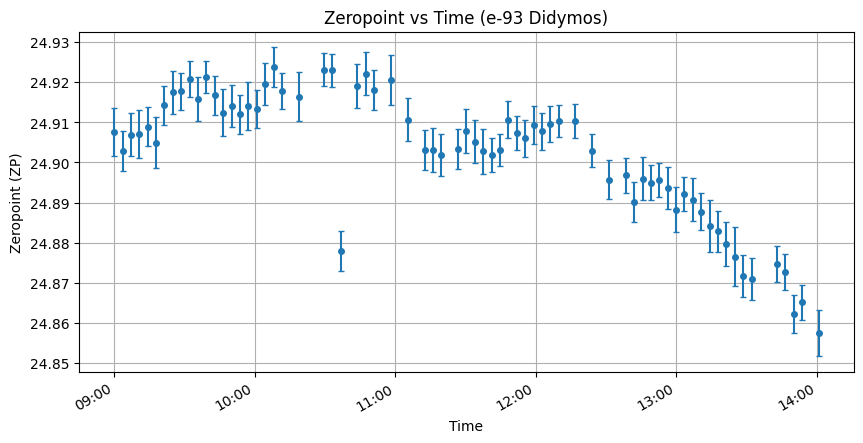

In [36]:
fig, ax = plt.subplots(1,1,figsize=(10,5))

ax.errorbar(
    time,
    zps,
    yerr=zps_err,
    fmt='o',
    markersize=4,
    capsize=2
)

ax.set_xlabel("Time")
ax.set_ylabel("Zeropoint (ZP)")
ax.set_title("Zeropoint vs Time (e-93 Didymos)")
plt.grid(True)

# make time axis readable
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gcf().autofmt_xdate()

plt.show()

In [37]:
###extract airmass ###

airmass = []
for path in table_g["path to frame"]:
    with fits.open(path) as hdul:
        header = hdul[0].header
        airmass.append(header["AIRMASS"])

    

/home/tlister/git/neoexchange-devel/neoexchange/core/management/commands/lightcurve_extraction.py:161: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show() #


Initial FWHM, seeing= 1.442 1.413 arcsec


/home/tlister/git/neoexchange-devel/neoexchange/core/management/commands/lightcurve_extraction.py:191: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig2.show() #


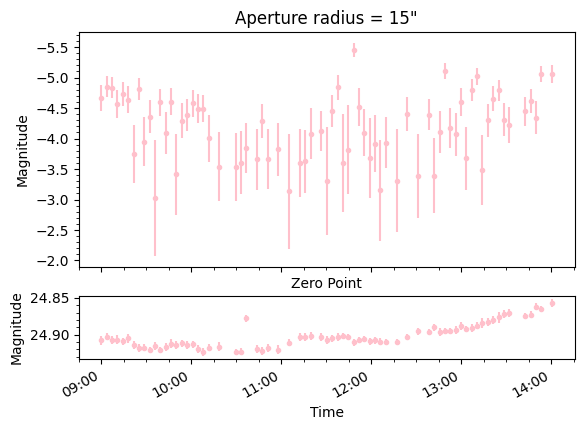

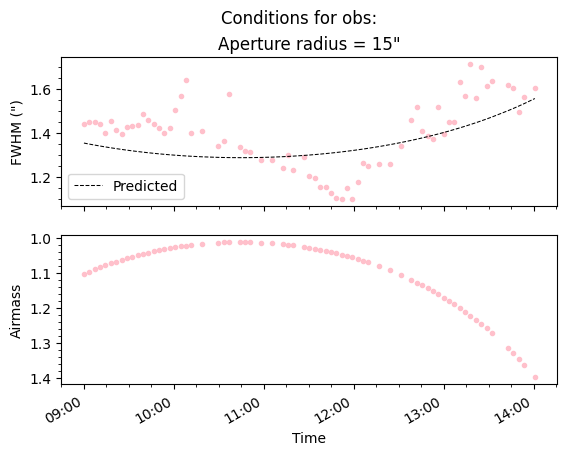

In [38]:
LC_command = Command()


LC_command.plot_timeseries(time,
                           time,
                           mags,
                           magerr,
                           zps,
                           zps_err,
                           fwhm,
                           airmass,
                           colors ="pink",
                           datadir = didymos_data,
                           filename = "tmp_7_12_LC_2",
                           sub_title = "Aperture radius = 15\"")

### r=8" (29.9 pixels) data

In [42]:
filepath_ecsv = os.path.join(didymos_photometry, "aper_p_Didymos2_712_06_13.ecsv")


table2 = Table.read(filepath_ecsv, format = "ascii.ecsv")
remap_frame_paths(table2)

columns = table2.columns

#mask bad columns wit high mag error
mask = (table2["magerr"] > 1) | (table2["aperture sum"] <0)
table_g2 = table2[~mask]

RA2 = table_g2["RA"]
dec2 = table_g2["DEC"]
time2 = table_g2['times'].to_datetime()
mags2 = table_g2["mag"]
magerr2 = table_g2["magerr"]
zps2 = table_g2["ZP"]
zps_err2 = table_g2["ZP_sig"]
fwhm2 = table_g2["FWHM"]
alltimes2 = table2["times"].to_datetime()
#airmass

print(table2["mag"][:10])

###extract airmass ###

airmass2 = []
for path in table_g2["path to frame"]:
    with fits.open(path) as hdul:
        header = hdul[0].header
        airmass2.append(header["AIRMASS"])

    


remap_frame_paths: 86 of 86 rows remapped onto /apophis/tlister/didymos_data/Hera_Didymos_data; 0 file(s) missing on disk
        mag        
-------------------
  -4.84944758722815
 -4.854825079600032
 -4.558988396209399
  -4.69009436795267
 -4.489947854041469
 -4.700585652892149
 -4.532978414439637
-4.9187943736377795
 -4.395026200250008
  -4.36095544370969


/home/tlister/git/neoexchange-devel/neoexchange/core/management/commands/lightcurve_extraction.py:161: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show() #


Initial FWHM, seeing= 1.442 1.413 arcsec


/home/tlister/git/neoexchange-devel/neoexchange/core/management/commands/lightcurve_extraction.py:191: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig2.show() #


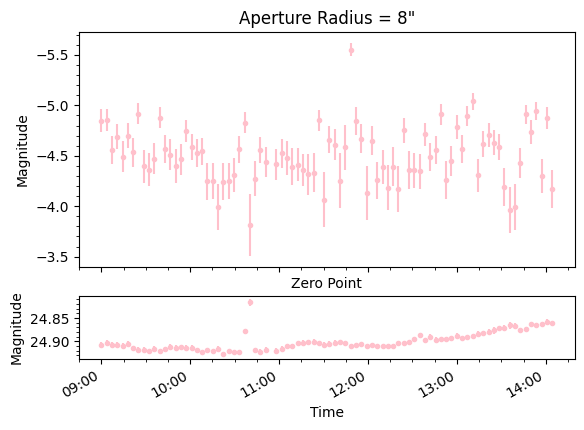

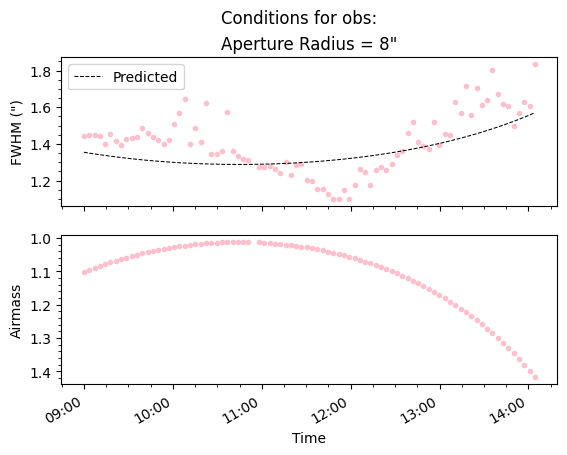

In [43]:
LC_command.plot_timeseries(time2,
                           time2,
                           mags2,
                           magerr2,
                           zps2,
                           zps_err2,
                           fwhm2,
                           airmass2,
                           colors ="pink",
                           datadir = didymos_data,
                           filename = "tmp_7_12_LC_8",
                        sub_title ="Aperture Radius = 8\"" )

### r=5" (18.7 pixels) data

In [45]:
filepath_ecsv = os.path.join(didymos_photometry, "aper_p_Didymos5_712_06_13.ecsv")


table5 = Table.read(filepath_ecsv, format = "ascii.ecsv")
remap_frame_paths(table5)

columns = table5.columns

#mask bad columns wit high mag error
mask = (table5["magerr"] > 1) | (table5["aperture sum"] < 0)
table_g5 = table5[~mask]

RA5 = table_g5["RA"]
dec5 = table_g5["DEC"]
time5 = table_g5['times'].to_datetime()
mags5 = table_g5["mag"]
magerr5 = table_g5["magerr"]
zps5 = table_g5["ZP"]
zps_err5 = table_g5["ZP_sig"]
fwhm5 = table_g5["FWHM"]
alltimes5 = table5["times"].to_datetime()
#airmass

print(np.min(table_g5["aperture sum"]))

###extract airmass ###

airmass5 = []
for path in table_g5["path to frame"]:
    with fits.open(path) as hdul:
        header = hdul[0].header
        airmass5.append(header["AIRMASS"])

    


remap_frame_paths: 86 of 86 rows remapped onto /apophis/tlister/didymos_data/Hera_Didymos_data; 0 file(s) missing on disk
52.853736735132095


/home/tlister/git/neoexchange-devel/neoexchange/core/management/commands/lightcurve_extraction.py:161: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show() #


Initial FWHM, seeing= 1.442 1.413 arcsec


/home/tlister/git/neoexchange-devel/neoexchange/core/management/commands/lightcurve_extraction.py:191: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig2.show() #


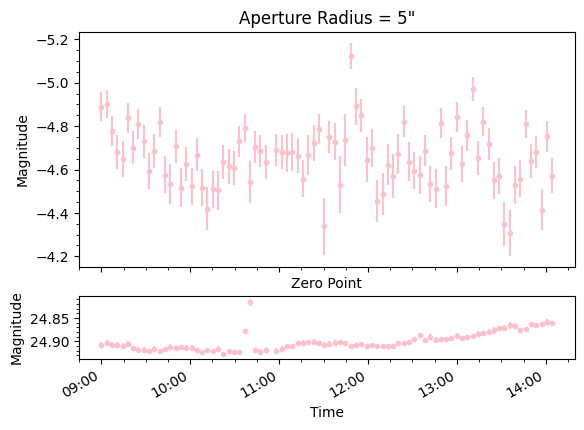

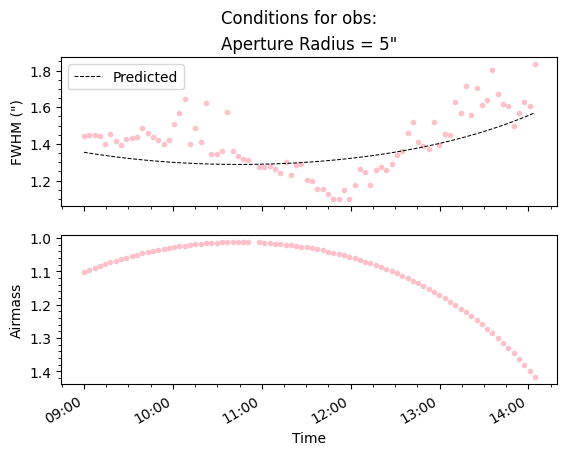

In [46]:
LC_command.plot_timeseries(time5,
                           time5,
                           mags5,
                           magerr5,
                           zps5,
                           zps_err5,
                           fwhm5,
                           airmass5,
                           colors ="pink",
                           datadir = didymos_data,
                           filename = "tmp_7_12_LC_5",
                        sub_title ="Aperture Radius = 5\"" )

### SNR comparison between apertures

In [52]:
###calculate rough estimate of SNR of 3 aperture sizes

##estimate equation is 1/sqrt(aperture_sum_err)

mean_SNR_ap_13 = np.mean(table_g["aperture sum"] / np.sqrt(table_g["aperture sum err"]))
mean_SNR_ap_8 = np.mean( table_g2["aperture sum"] / np.sqrt(table_g2["aperture sum err"]))
mean_SNR_ap_5 = np.mean( table_g5["aperture sum"] / np.sqrt(table_g5["aperture sum err"]))


print(f"-------------------------\n"
      f"Mean SNR with aperture radius at 13\" ({(13*u.arcsec)/pixel_scale:.2f}): {mean_SNR_ap_13}\n"
      f"Mean SNR with aperture radius at  8\" ({(8*u.arcsec)/pixel_scale:.2f}): {mean_SNR_ap_8}\n"
      f"Mean SNR with aperture radius at  5\" ({(5*u.arcsec)/pixel_scale:.2f}): {mean_SNR_ap_5}\n"
      )



-------------------------
Mean SNR with aperture radius at 13" (48.64 pix): 14.058520458756075
Mean SNR with aperture radius at  8" (29.93 pix): 22.23071999626583
Mean SNR with aperture radius at  5" (18.71 pix): 31.406153713621975



In [53]:
filepath_ecsv = os.path.join(didymos_photometry, "aper_p_Didymos5snr_712_06_13.ecsv")


table5s = Table.read(filepath_ecsv, format = "ascii.ecsv")
remap_frame_paths(table5s)

columns = table5s.columns

#mask bad columns wit high mag error
mask = (table5s["magerr"] > 1) | (table5s["aperture sum"] < 0)
table_g5s = table5s[~mask]

RA5s = table_g5s["RA"]
dec5s = table_g5s["DEC"]
time5s = table_g5s['times'].to_datetime()
mags5s = table_g5s["mag"]
magerr5s = table_g5s["magerr"]
zps5s = table_g5s["ZP"]
zps_err5s = table_g5s["ZP_sig"]
fwhm5s = table_g5s["FWHM"]
alltimes5s = table5s["times"].to_datetime()
#airmass

print(table_g5s.colnames)

###extract airmass ###

airmass5s = []
for path in table_g5s["path to frame"]:
    with fits.open(path) as hdul:
        header = hdul[0].header
        airmass5s.append(header["AIRMASS"])

    


remap_frame_paths: 86 of 86 rows remapped onto /apophis/tlister/didymos_data/Hera_Didymos_data; 0 file(s) missing on disk
['path to frame', 'times', 'filters', 'RA', 'DEC', 'xcenter', 'ycenter', 'aperture sum', 'aperture sum err', 'FWHM', 'ZP', 'ZP_sig', 'mag', 'magerr', 'aperture radius', 'SNR']


/home/tlister/git/neoexchange-devel/neoexchange/core/management/commands/lightcurve_extraction.py:161: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show() #


Initial FWHM, seeing= 1.442 1.413 arcsec


/home/tlister/git/neoexchange-devel/neoexchange/core/management/commands/lightcurve_extraction.py:191: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig2.show() #


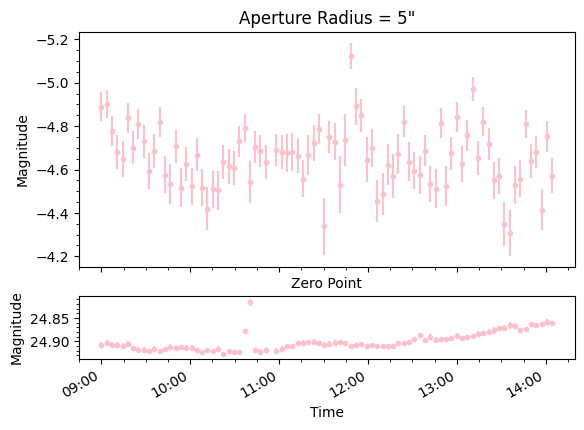

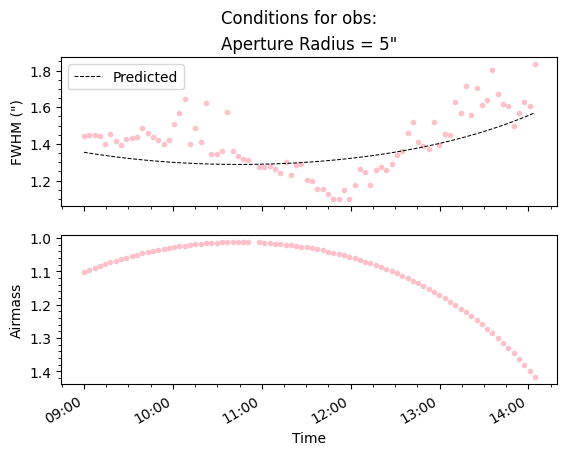

In [54]:
LC_command.plot_timeseries(time5s,
                           time5s,
                           mags5s,
                           magerr5s,
                           zps5s,
                           zps_err5s,
                           fwhm5s,
                           airmass5s,
                           colors ="pink",
                           datadir = didymos_data,
                           filename = "tmp_7_12_LC_5s",
                        sub_title ="Aperture Radius = 5\"" )

#change final title: Light Curve Coj 2026-07-12

remap_frame_paths: 86 of 86 rows remapped onto /apophis/tlister/didymos_data/Hera_Didymos_data; 0 file(s) missing on disk
['path to frame', 'times', 'filters', 'RA', 'DEC', 'xcenter', 'ycenter', 'aperture sum', 'aperture sum err', 'FWHM', 'ZP', 'ZP_sig', 'mag', 'magerr', 'aperture radius', 'SNR']


/home/tlister/git/neoexchange-devel/neoexchange/core/management/commands/lightcurve_extraction.py:161: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show() #


Initial FWHM, seeing= 1.442 1.413 arcsec


/home/tlister/git/neoexchange-devel/neoexchange/core/management/commands/lightcurve_extraction.py:191: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig2.show() #


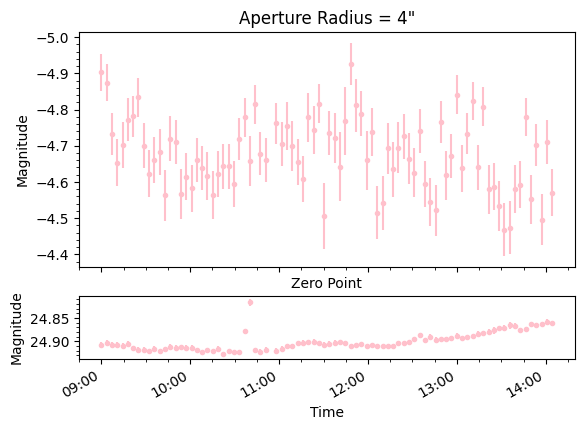

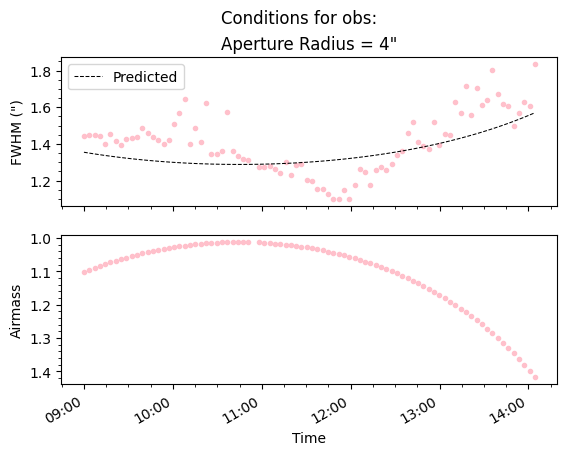

In [55]:
filepath_ecsv_4 = os.path.join(didymos_photometry, "aper_p_Didymos_712_06_4.ecsv")


table4 = Table.read(filepath_ecsv_4, format = "ascii.ecsv")
remap_frame_paths(table4)

columns = table4.columns

#mask bad columns wit high mag error
mask = (table4["magerr"] > 1) | (table4["aperture sum"] < 0)
table_g4s = table4[~mask]

RA4s = table_g4s["RA"]
dec4s = table_g4s["DEC"]
time4s = table_g4s['times'].to_datetime()
mags4s = table_g4s["mag"]
magerr4s = table_g4s["magerr"]
zps4s = table_g4s["ZP"]
zps_err4s = table_g4s["ZP_sig"]
fwhm4s = table_g4s["FWHM"]
alltimes4s = table_g4s["times"].to_datetime()
#airmass

print(table_g4s.colnames)

###extract airmass ###

airmass4s = []
for path in table_g4s["path to frame"]:
    with fits.open(path) as hdul:
        header = hdul[0].header
        airmass4s.append(header["AIRMASS"])

    
 
LC_command.plot_timeseries(time4s,
                           time4s,
                           mags4s,
                           magerr4s,
                           zps4s,
                           zps_err4s,
                           fwhm4s,
                           airmass4s,
                           colors ="pink",
                           datadir = didymos_data,
                           filename = "tmp_7_12_LC_4s",
                        sub_title ="Aperture Radius = 4\"" )

In [56]:
#mean SNR of radius = 5
print(f"mean SNR with r =5 px is:{np.mean(table_g5s['SNR']):.3f} ")
print(f"mean SNR with r =8 px is:{np.mean(table_g2['SNR']):.3f} ")
print(f"mean SNR with r =13 px is:{np.mean(table_g['SNR']):.3f} ")
print([f'{snr:.3f}' for snr in table_g4s['SNR']])

print(f"mean SNR with r =5 px is:{ np.mean(table_g5s['aperture sum']/np.sqrt(table_g5s['aperture sum err']))}") 




mean SNR with r =5 px is:13.445 
mean SNR with r =8 px is:7.531 
mean SNR with r =13 px is:3.745 
['20.810', '21.103', '18.617', '16.614', '17.154', '18.425', '19.393', '20.105', '17.329', '16.785', '16.870', '17.228', '15.558', '17.353', '17.577', '15.771', '17.008', '16.472', '17.600', '17.865', '16.401', '16.501', '16.985', '17.512', '17.461', '16.766', '18.664', '20.173', '15.561', '20.261', '18.431', '17.815', '19.277', '17.918', '16.681', '15.798', '16.839', '16.928', '16.123', '16.566', '20.048', '12.000', '17.741', '15.693', '11.437', '11.664', '18.560', '14.832', '17.362', '13.370', '16.248', '14.912', '14.676', '15.466', '14.154', '15.327', '17.308', '15.447', '16.045', '17.970', '17.087', '16.644', '15.335', '18.839', '16.116', '17.978', '19.867', '16.692', '18.846', '20.814', '17.518', '20.172', '15.977', '16.787', '15.767', '14.999', '14.967', '16.337', '16.720', '20.286', '16.043', '18.737', '15.539', '17.841', '16.825']
mean SNR with r =5 px is:31.406153713621975


In [ ]:
#select file names where mag error > 1 or aperture photometry <= 0:
#select files with any nan values and say what is nan
#

filepath_ecsv_13 = os.path.join(didymos_photometry, "aper_p_Didymos_712_06_13.ecsv")
filepath_ecsv_5 = os.path.join(didymos_photometry, "aper_p_Didymos5snr_712_06_13.ecsv")
filepath_ecsv_8 = os.path.join(didymos_photometry, "aper_p_Didymos2_712_06_13.ecsv")
filepath_ecsv_4 = os.path.join(didymos_photometry, "aper_p_Didymos_712_06_4.ecsv")

table_13 = Table.read(filepath_ecsv_13, format = "ascii.ecsv")
remap_frame_paths(table_13)
table_8 = Table.read(filepath_ecsv_8, format = "ascii.ecsv")
remap_frame_paths(table_8)
table_5 = Table.read(filepath_ecsv_5, format = "ascii.ecsv")
remap_frame_paths(table_5)
table_4 = Table.read(filepath_ecsv_4, format = "ascii.ecsv")
remap_frame_paths(table_4)

cols = ["aperture sum", "ZP","mag" ]
nan_mask = np.any([np.isnan(table_13[c])for c in cols], axis = 0) 
mag_mask =  (table_13["aperture sum"] <= 0) #bad aperture
bad_magerr = table_13["magerr"] > 1  #high error in mag

issue_mask = nan_mask | mag_mask | bad_magerr  #files will get flagged for any isue listed       

for i, flagged in enumerate(issue_mask):
    if not flagged:
          continue

    if flagged:
         issues = []

    if nan_mask[i]:
        bad_cols = [c for c in cols if np.isnan(table_13[c][i])]
        print(f"{table_13['path to frame'][i]} has nan in {bad_cols}")
        issues.append(f"{table_13['path to frame'][i]} has nan in {bad_cols}")

    if bad_magerr[i]:
            issues.append(f"{table_13['path to frame'][i]} has magger = {table_13['magerr'][i]}")
            print(f"{table_13['path to frame'][i]} has magger = {table_13['magerr'][i]}")
    if mag_mask[i]:
         issues.append(f"{table_13['path to frame'][i]} has aperture_sum = {table_13['aperture sum'][i]}")
         print(f"{table_13['path to frame'][i]} has aperture_sum = {table_13['aperture sum'][i]}")

    if mag_mask[i] and bad_magerr[i]:
            issues.append(f"{table_13['path to frame'][i]} has magger = {table_13['magerr'][i]} \n" 
                          f" and has aperture_sum = {table_13['aperture sum'][i]}")
            print(f"{table_13['path to frame'][i]} has magger = {table_13['magerr'][i]} /m" 
                  f"and aperture_sum = {table_13['aperture sum'][i]}")



remap_frame_paths: 86 of 86 rows remapped onto /apophis/tlister/didymos_data/Hera_Didymos_data; 0 file(s) missing on disk
remap_frame_paths: 86 of 86 rows remapped onto /apophis/tlister/didymos_data/Hera_Didymos_data; 0 file(s) missing on disk
remap_frame_paths: 86 of 86 rows remapped onto /apophis/tlister/didymos_data/Hera_Didymos_data; 0 file(s) missing on disk
remap_frame_paths: 86 of 86 rows remapped onto /apophis/tlister/didymos_data/Hera_Didymos_data; 0 file(s) missing on disk
/apophis/tlister/didymos_data/Hera_Didymos_data/f06_012_e93/coj2m002-ep07-20260712-0079-e93.fits has nan in ['mag']
/apophis/tlister/didymos_data/Hera_Didymos_data/f06_012_e93/coj2m002-ep07-20260712-0079-e93.fits has aperture_sum = -7.130750342360114
/apophis/tlister/didymos_data/Hera_Didymos_data/f06_012_e93/coj2m002-ep07-20260712-0081-e93.fits has nan in ['mag']
/apophis/tlister/didymos_data/Hera_Didymos_data/f06_012_e93/coj2m002-ep07-20260712-0081-e93.fits has aperture_sum = -6.686866421599019
/apophis/t

## Looking at quality of subtractions

In [19]:
###Look at subtraction quality of e-93's

sub_save_path = os.path.join(didymos_data, "subtraction_analysis")
bad_files = [
    "coj2m002-ep07-20260712-0079-e93.fits",
    "coj2m002-ep07-20260712-0081-e93.fits",
    "coj2m002-ep07-20260712-0082-e93.fits",
    "coj2m002-ep07-20260712-0086-e93.fits",
    "coj2m002-ep07-20260712-0090-e93.fits",
    "coj2m002-ep07-20260712-0092-e93.fits",
    "coj2m002-ep07-20260712-0094-e93.fits",
    "coj2m002-ep07-20260712-0098-e93.fits",
    "coj2m002-ep07-20260712-0112-e93.fits",
    "coj2m002-ep07-20260712-0114-e93.fits",
    "coj2m002-ep07-20260712-0116-e93.fits",
    "coj2m002-ep07-20260712-0118-e93.fits",
    "coj2m002-ep07-20260712-0135-e93.fits",
    "coj2m002-ep07-20260712-0136-e93.fits",
    "coj2m002-ep07-20260712-0141-e93.fits",
    "coj2m002-ep07-20260712-0143-e93.fits",
]

bad_blocks = []
for fname in bad_files:
    frame = Frame.objects.filter(filename__contains = fname).first()
    if fname and frame:
        bad_blocks.append(frame.block.id)
        print(f"{fname}, block: {frame.block.id}")
    else:
        print(f"{fname}, NOT FOUND")


coj2m002-ep07-20260712-0079-e93.fits, block: 35906
coj2m002-ep07-20260712-0081-e93.fits, block: 35906
coj2m002-ep07-20260712-0082-e93.fits, block: 35906
coj2m002-ep07-20260712-0086-e93.fits, block: 35906
coj2m002-ep07-20260712-0090-e93.fits, block: 35906
coj2m002-ep07-20260712-0092-e93.fits, block: 35906
coj2m002-ep07-20260712-0094-e93.fits, block: 35906
coj2m002-ep07-20260712-0098-e93.fits, block: 35906
coj2m002-ep07-20260712-0112-e93.fits, block: 35906
coj2m002-ep07-20260712-0114-e93.fits, block: 35906
coj2m002-ep07-20260712-0116-e93.fits, block: 35906
coj2m002-ep07-20260712-0118-e93.fits, block: 35906
coj2m002-ep07-20260712-0135-e93.fits, block: 35906
coj2m002-ep07-20260712-0136-e93.fits, block: 35906
coj2m002-ep07-20260712-0141-e93.fits, block: 35906
coj2m002-ep07-20260712-0143-e93.fits, block: 35906


In [20]:

###use this to make heat map plots of flux values of the fits that we can open with ds9###


obs_block_bad = Block.objects.get(id =bad_blocks[0])
data_storage_filename, badness_storage_filename, bad_filenames, percent_bad_files = examine_subtractions(
                                    obs_block_bad,
                                    sub_save_path,
                                    overwrite = True
 )

try:
    for f in bad_filenames:
        print(f"detected bad frame: {f}")
except IndexError as exc:
    raise IndexError("No files found") from exc

print(f"percent of bad files: {percent_bad_files}")

detected bad frame: coj2m002-ep07-20260712-0086-e93.fits
detected bad frame: coj2m002-ep07-20260712-0090-e93.fits
percent of bad files: 2.3255813953488373


In [21]:
###access datatable with bad subtraction files

#---i.e colname = bad_subtraction = True

file_path_ecsv_bad = os.path.join(didymos_data, "subtraction_analysis", "examined_subtractions_table_2026-07-12.ecsv")

table_bad = Table.read(file_path_ecsv_bad, format = "ascii.ecsv")

#select rows with flagged bad tables == True
mask = table_bad["bad_subtraction"] == True

table_bad = table_bad[mask]

for c in table_bad.colnames[:-1]:
    print("-------------")
    for val in table_bad[c]:
        try:
            print(f"{c}  {val:.3f} ")
        except (ValueError,TypeError):
            print(val)


#super negative SNR when we get the weird bock distortions -- can use this to recognize them

-------------
mean_up_left  -7.281 
mean_up_left  13.495 
-------------
mean_up_mid  -0.358 
mean_up_mid  0.509 
-------------
mean_up_right  -4.911 
mean_up_right  2.972 
-------------
mean_mid_left  -2.897 
mean_mid_left  -1014.296 
-------------
mean_mid_mid  -2.531 
mean_mid_mid  -2880.352 
-------------
mean_mid_right  -27.027 
mean_mid_right  -445.786 
-------------
mean_low_left  9.881 
mean_low_left  5.263 
-------------
mean_low_mid  -2258.931 
mean_low_mid  38.694 
-------------
mean_low_right  -8.655 
mean_low_right  -7.057 
-------------
std_up_left  33.614 
std_up_left  38.369 
-------------
std_up_mid  33.541 
std_up_mid  35.547 
-------------
std_up_right  34.914 
std_up_right  31.079 
-------------
std_mid_left  34.286 
std_mid_left  422.647 
-------------
std_mid_mid  35.331 
std_mid_mid  104.089 
-------------
std_mid_right  41.745 
std_mid_right  38.154 
-------------
std_low_left  39.383 
std_low_left  33.400 
-------------
std_low_mid  133.535 
std_low_mid  70.841 

In [22]:
###make a gif using the frames--e-93
import glob

frames = []

data_path = os.path.join(didymos_data, "f06_012_e93")
for f in glob.glob(os.path.join(data_path, "*.fits*")):
    if "rms" not in f:
        frames.append(f)
movie_file = make_gif(frames,
                      title = "Observation: Didymos 202607012",
                      sort=True, init_fr=100, 
                      center=3, 
                      out_path=data_path, 
                      plot_source=True,
                      target_data=None,
                      show_reticle=True, 
                      progress=True)

Creating Gif: Frame 86 |████████████████████████████████████████████████████████████████████████████████████████████████████| 100.0%| 0.0 sec remaining |


## Investigate SNR and mag scatter as a function of time
Comparing `NEOexchange` vs `PhotPipe` results

In [ ]:
####TASK-####

#Plot SNR and mag scatter by file/point -- NEOx aperture phot from lightcurve_extraction
#plot SNR and mag scatter from PhotPipe aperutre photometry
#repeat for DIA aperture photometry ??

#find frames with high scatter, large offsets

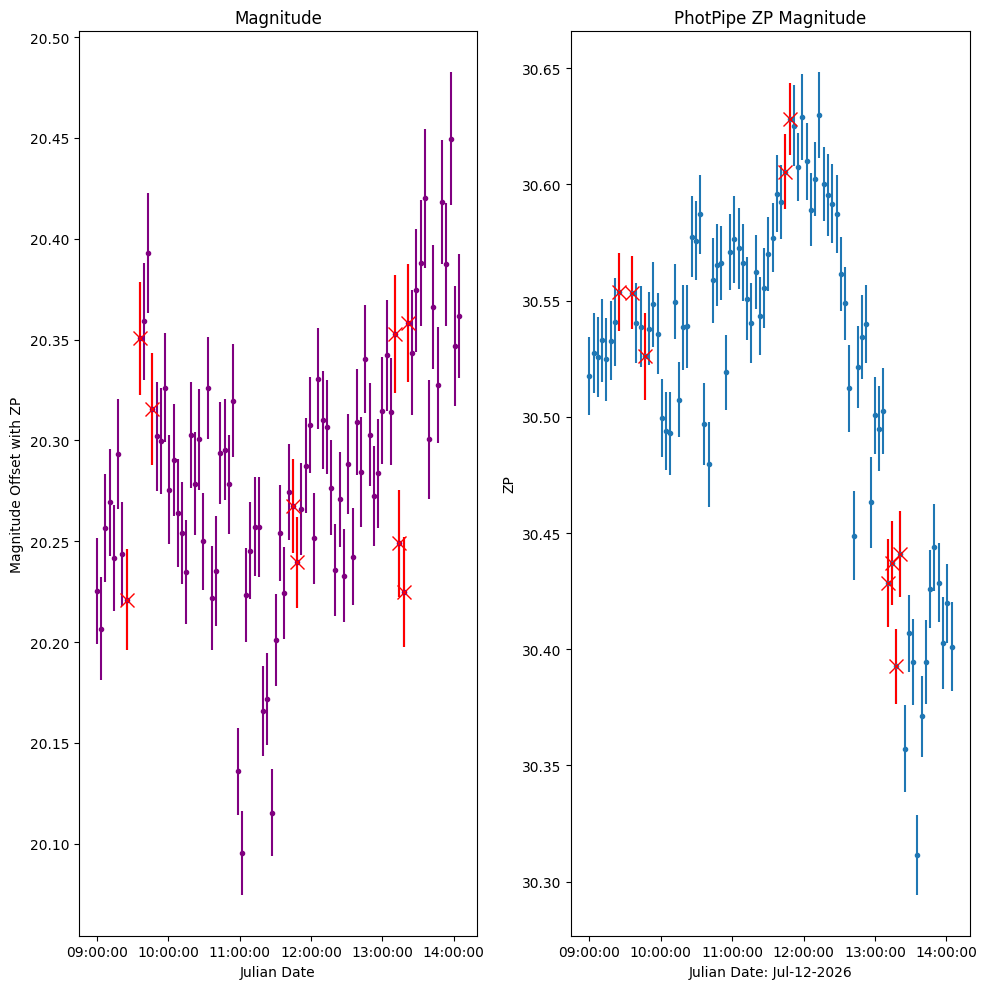

In [57]:
#photPipe analysis ---DART format LC file 7/12/26
from pathlib import Path

import matplotlib.dates as mdates

Phot_path = Path(didymos_data, "subtraction_analysis/lcogt_coj-PP_ep07_20260712_4253588_65803didymos_photometry.tab")
Phot_pipe_table = Table.read(Phot_path, format = "ascii")

Phot_pipe_table.sort('julian_date')


julian_date= Phot_pipe_table['julian_date']
times = Time(julian_date, format='jd').datetime

mag = Phot_pipe_table['mag']
mag_err = Phot_pipe_table['inst_sig']
ZP = Phot_pipe_table['ZP']
ZP_err = Phot_pipe_table['ZP_sig']

flag = Phot_pipe_table["SExtractor_flag"]
bad_flag = flag > 0

fig, ax = plt.subplots(1,2, figsize = (10,10))

# magnitude plot
ax[0].errorbar(times,mag, yerr =mag_err, fmt = '.',color = "purple")
ax[0].set_xlabel("Julian Date")
ax[0].set_ylabel("Magnitude Offset with ZP")
ax[0].set_title("Magnitude")

# flagged points
ax[0].errorbar(
    times[bad_flag],
    mag[bad_flag],
    yerr=mag_err[bad_flag],
    fmt='x',
    color='red',
    markersize=10,
    label="SExtractor flag > 0"
)

#ax[0].invert_yaxis()

# ZP plot
ax[1].errorbar(times,ZP, yerr =ZP_err, fmt = '.')
ax[1].set_xlabel("Julian Date: Jul-12-2026")
ax[1].set_ylabel("ZP")
#ax[1].invert_yaxis()
ax[1].set_title("ZP")

ax[0].xaxis.set_major_formatter(
    mdates.DateFormatter('%H:%M:%S')
)

# flagged points
ax[1].errorbar(
    times[bad_flag],
    ZP[bad_flag],
    yerr=ZP_err[bad_flag],
    fmt='x',
    color='red',
    markersize=10,
    label="SExtractor flag > 0"
)

ax[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.title('PhotPipe ZP Magnitude')
plt.tight_layout()
plt.show()





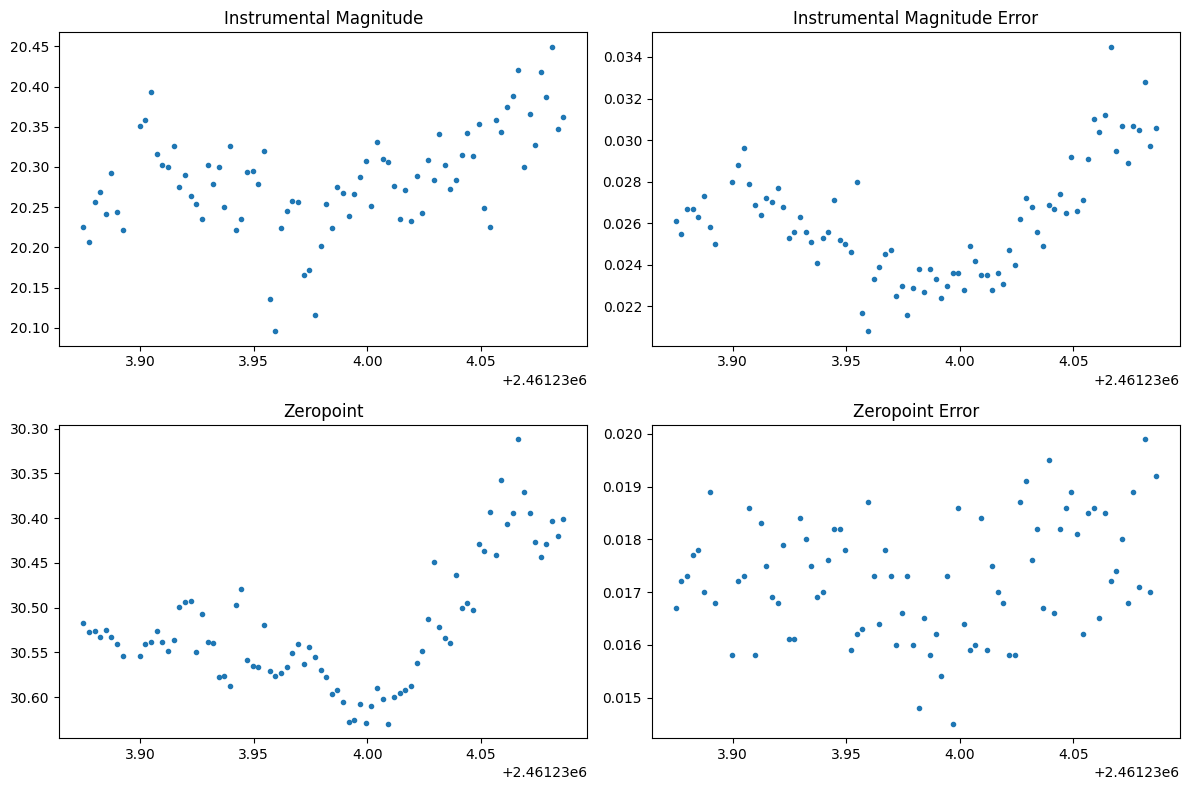

In [58]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

ax[0,0].plot(julian_date, mag, '.')
ax[0,0].invert_yaxis()
ax[0,0].set_title("Instrumental Magnitude")
ax[0,0].invert_yaxis()

ax[0,1].plot(julian_date, mag_err, '.')
ax[0,1].set_title("Instrumental Magnitude Error")

ax[1,0].plot(julian_date, ZP, '.')
ax[1,0].set_title("Zeropoint")
ax[1,0].invert_yaxis()

ax[1,1].plot(julian_date, ZP_err, '.')
ax[1,1].set_title("Zeropoint Error")

plt.tight_layout()
plt.show()

### SNR over time

Maximum mag error: 0.0345
Frame: coj2m002-ep07-20260712-0058-e92.fits


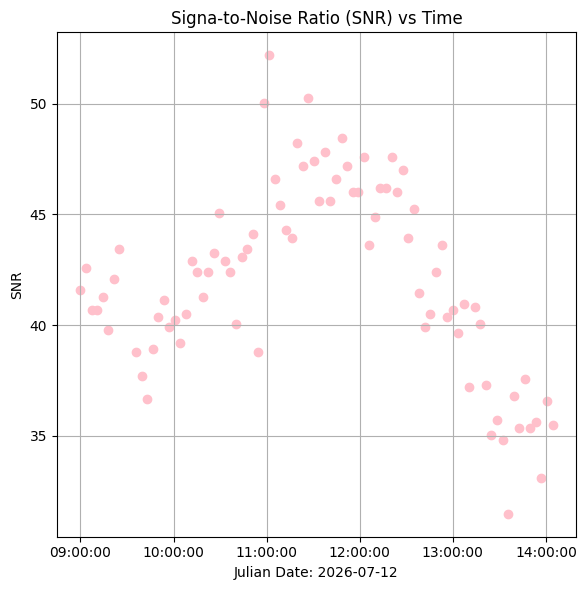

In [59]:
max_mag_error = Phot_pipe_table['inst_sig'].max()
max_err_frame = Phot_pipe_table['file'][max_mag_error.argmax()]

print(f"Maximum mag error: {max_mag_error:.4f}\n"
      f"Frame: {max_err_frame}")


#get flux
flux = 10**(-0.4*(Phot_pipe_table['inst_mag']-Phot_pipe_table['ZP']))
snr = 1.0857 / Phot_pipe_table["inst_sig"]

fig , ax = plt.subplots(figsize=(6,6))

ax.scatter(times,snr, marker = 'o', color = 'pink')
ax.set_xlabel("Julian Date: 2026-07-12")
ax.set_ylabel("SNR")
ax.set_title("Signa-to-Noise Ratio (SNR) vs Time")

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

plt.grid()
plt.tight_layout()
plt.show()

### SNR vs airmass

In [ ]:
###---plot SNR against Airmass----###

# Acquire RA and Dec from field files 

ra_e92 =[]
dec_e92 = []

files_e92 = list(Phot_pipe_table['file'])
frame = Frame.objects.filter(filename__in = files_e92)

for f in frame:
    
    block = f.block
    field_sources = StaticSource.objects.filter(block=block)
    
    for s in field_sources:

        ra_e92.append(s.ra)
        dec_e92.append(s.dec)

In [61]:
### Transform ra, dec ---> alt, az

c = SkyCoord(ra = ra_e92 *u.deg, dec = dec_e92 * u.deg, frame = 'icrs')
t = Time(julian_date, format = 'jd')
location = EarthLocation(
    lat=-31.2733*u.deg,
    lon=149.0719*u.deg,
    height=1165*u.m
)
c_alt_az = c.transform_to(AltAz(obstime = t, location = location))

airmass = c_alt_az.secz

In [62]:
# print(c_alt_az.alt)
# print(c_alt_az.secz)
print(c_alt_az.alt)
print(airmass.min(), airmass.max())

[64d57m40.34522014s 65d42m11.88245955s 66d26m32.04244992s
 67d10m35.17368139s 67d54m24.73459209s 68d37m57.18533639s
 69d21m12.87644907s 70d04m08.02955546s 72d10m26.23127216s
 72d51m32.36452983s 73d32m04.98340539s 74d11m53.86689524s
 74d50m56.76126358s 75d29m06.29233607s 76d06m17.90687426s
 76d42m19.65446527s 77d17m04.14286873s 77d50m19.92493457s
 78d21m51.09596621s 78d51m25.78541772s 79d18m46.8838137s
 79d43m35.89268797s 80d05m34.67782379s 80d24m23.49441293s
 80d39m43.40324177s 80d51m16.05214715s 80d58m47.36945386s
 81d02m07.10910104s 81d01m10.77349666s 80d55m59.60426812s
 80d46m41.05735186s 80d33m26.51564676s 80d16m31.34713613s
 79d56m16.4290404s 79d33m00.52917399s 79d07m03.10182642s
 78d38m41.80653025s 78d08m14.23436492s 77d35m56.33253233s
 77d02m00.57541862s 76d26m42.1426688s 75d50m08.0176969s 75d12m30.30452361s
 74d33m55.85283332s 73d54m31.84619626s 73d14m23.8660828s
 72d33m37.25568672s 71d52m16.5792263s 71d10m25.4098054s 70d28m07.52039125s
 69d45m25.64963492s 69d02m22.36731939s 68

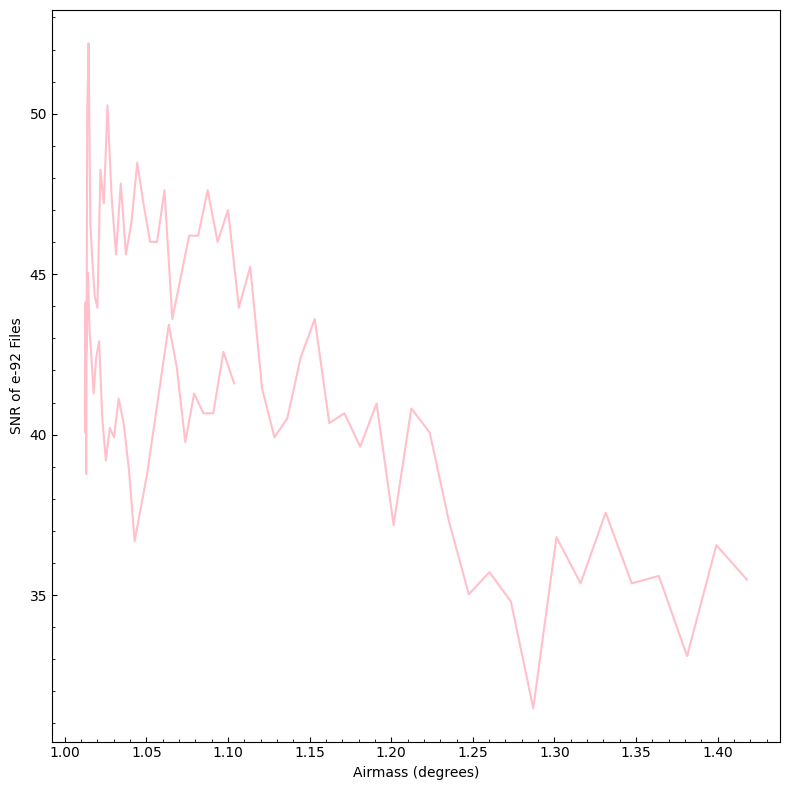

In [63]:
fig, ax = plt.subplots(1,1,figsize = (8,8))
z = np.degrees(np.arccos(1/airmass))
ax.plot(airmass,snr,color = "pink")
ax.set_xlabel("Airmass (degrees)")
ax.set_ylabel("SNR of e-92 Files")

# major ticks
ax.yaxis.set_major_locator(plt.MultipleLocator(5))
ax.xaxis.set_major_locator(plt.MultipleLocator(0.05))

ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax.tick_params(
    axis='both',
    which='both',
    direction='in',
    bottom=True,
    left=True
)

plt.tight_layout()
plt.show()


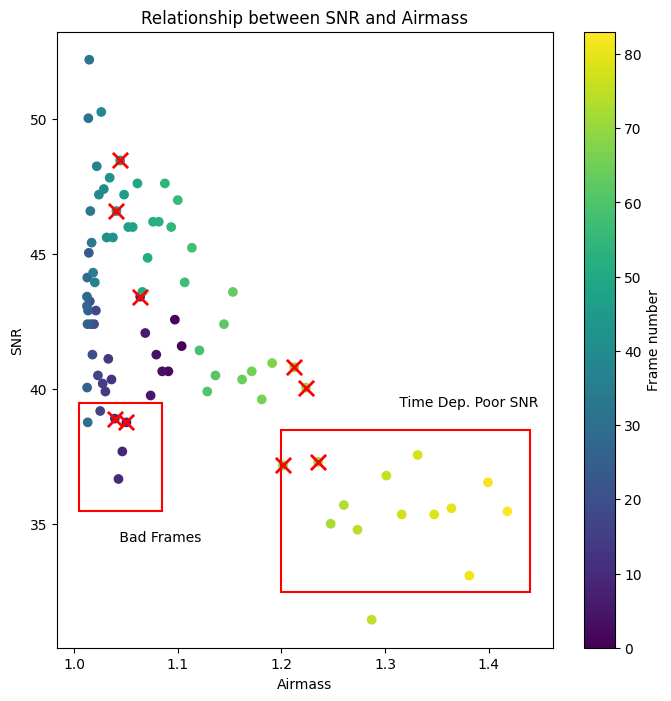

In [64]:
fig, ax = plt.subplots(figsize=(8,8))

flag = Phot_pipe_table["SExtractor_flag"]
bad_flag = flag > 0



sc = ax.scatter(
    airmass,
    snr,
    c=np.arange(len(snr)),
    cmap="viridis"
)

# highlight SExtractor flagged frames
ax.scatter(
    airmass[bad_flag],
    snr[bad_flag],
    marker="x",
    s=120,
    linewidths=2,
    color="red",
    label="SExtractor flag > 0"
)
#highlight certain areas
box_bad = Rectangle(
    (1.03 -0.05/2, 37 - 3/2), 
     0.08,   #width in x
     4, #height in y
     fill = False,
     linewidth = 1.5,
     color = "red" 
)

box_time = Rectangle(
    (1.29 - 0.18/2, 35 -5/2), 
     0.24,   #width in x
     6, #height in y
     fill = False,
     linewidth = 1.5, 
     color = "red"
)

ax.add_patch(box_bad)
ax.add_patch(box_time)

 # label point
ax.annotate(
    " Bad Frames",
    (1.03, 34),
    xytext=(7, 7),
    textcoords="offset points"
)

 # label point
ax.annotate(
    " Time Dep. Poor SNR",
    (1.30, 39),
    xytext=(7, 7),
    textcoords="offset points"
)


ax.set_xlabel("Airmass")
ax.set_ylabel("SNR")
ax.set_title("Relationship between SNR and Airmass")
plt.colorbar(sc, label="Frame number")
plt.show()

In [65]:
#frames with snr < 38 ---bad frames --will also further divide by airmass x-axis for boxes

mask = snr <38

for i in np.where(mask)[0]:
    print("---------------------------------------")
    print(f"{Phot_pipe_table['file'][i]}")
    print(f"Frame {i}: Airmass={airmass[i]:.3f}, SNR={snr[i]:.2f}")



---------------------------------------
coj2m002-ep07-20260712-0069-e92.fits
Frame 9: Airmass=1.046, SNR=37.70
---------------------------------------
coj2m002-ep07-20260712-0070-e92.fits
Frame 10: Airmass=1.043, SNR=36.68
---------------------------------------
coj2m002-ep07-20260712-0128-e92.fits
Frame 68: Airmass=1.201, SNR=37.18
---------------------------------------
coj2m002-ep07-20260712-0131-e92.fits
Frame 71: Airmass=1.235, SNR=37.31
---------------------------------------
coj2m002-ep07-20260712-0132-e92.fits
Frame 72: Airmass=1.248, SNR=35.02
---------------------------------------
coj2m002-ep07-20260712-0133-e92.fits
Frame 73: Airmass=1.260, SNR=35.71
---------------------------------------
coj2m002-ep07-20260712-0134-e92.fits
Frame 74: Airmass=1.273, SNR=34.80
---------------------------------------
coj2m002-ep07-20260712-0135-e92.fits
Frame 75: Airmass=1.287, SNR=31.47
---------------------------------------
coj2m002-ep07-20260712-0136-e92.fits
Frame 76: Airmass=1.301, SNR

In [66]:
#-----cross check with midpoint values----#


frames_test = (Frame.objects.filter(
        block_id=35906,
        frametype=Frame.NEOX_RED_FRAMETYPE,
        filter='rp'
    ).order_by('midpoint')
    .values(
        'filename',
        'midpoint',
        'zeropoint',
        'zeropoint_err',
        'exptime',
        'fwhm'
    )
)

for f in frames_test:
    print(
        f"{f['midpoint']}  "
        f"ZP={f['zeropoint']:.3f} ± {f['zeropoint_err']:.3f}  "
        f"FWHM={f['fwhm']:.3f}  "
        f"{f['filename']}"
    )


2026-07-12 08:59:58.809000  ZP=24.789 ± 0.011  FWHM=1.442  coj2m002-ep07-20260712-0058-e92.fits
2026-07-12 09:03:33.919000  ZP=24.795 ± 0.011  FWHM=1.450  coj2m002-ep07-20260712-0059-e92.fits
2026-07-12 09:07:09.063000  ZP=24.797 ± 0.010  FWHM=1.450  coj2m002-ep07-20260712-0060-e92.fits
2026-07-12 09:10:43.888000  ZP=24.801 ± 0.011  FWHM=1.443  coj2m002-ep07-20260712-0061-e92.fits
2026-07-12 09:14:18.787000  ZP=24.794 ± 0.010  FWHM=1.399  coj2m002-ep07-20260712-0062-e92.fits
2026-07-12 09:17:53.615000  ZP=24.801 ± 0.010  FWHM=1.455  coj2m002-ep07-20260712-0063-e92.fits
2026-07-12 09:21:28.540000  ZP=24.808 ± 0.010  FWHM=1.416  coj2m002-ep07-20260712-0064-e92.fits
2026-07-12 09:25:03.442000  ZP=24.814 ± 0.010  FWHM=1.396  coj2m002-ep07-20260712-0065-e92.fits
2026-07-12 09:28:38.269000  ZP=24.809 ± 0.011  FWHM=1.428  coj2m002-ep07-20260712-0066-e92.fits
2026-07-12 09:32:13.113000  ZP=24.813 ± 0.011  FWHM=1.432  coj2m002-ep07-20260712-0067-e92.fits
2026-07-12 09:35:48.040000  ZP=24.814 ± 

#### Spot check a single frame to see if FWHM and ZP values are consistent across different frame types

In [74]:
for frame in Frame.objects.filter(
    block_id=35906,
    filename__startswith="coj2m002-ep07-20260712-0086",
    frametype__in=[Frame.BANZAI_RED_FRAMETYPE, Frame.NEOX_RED_FRAMETYPE, Frame.NEOX_SUB_FRAMETYPE]
).order_by('frametype'):
    ZP = frame.zeropoint or -99.0
    ZP_err = frame.zeropoint_err or -99.0
    FWHM = frame.fwhm or -99.0
    print(
        f"{frame.filename:>42s} ({frame.frametype}): ZP={ZP: 6.3f} ± {ZP_err: 7.3f} FWHM={FWHM:.3f}"
    )

      coj2m002-ep07-20260712-0086-e91.fits (91): ZP=-99.000 ± -99.000 FWHM=1.360
      coj2m002-ep07-20260712-0086-e92.fits (92): ZP= 24.736 ±   0.010 FWHM=1.360
      coj2m002-ep07-20260712-0086-e93.fits (93): ZP= 24.816 ±   0.007 FWHM=1.360


## Zeropoint cross checks

remap_frame_paths: 86 of 86 rows remapped onto /apophis/tlister/didymos_data/Hera_Didymos_data; 0 file(s) missing on disk


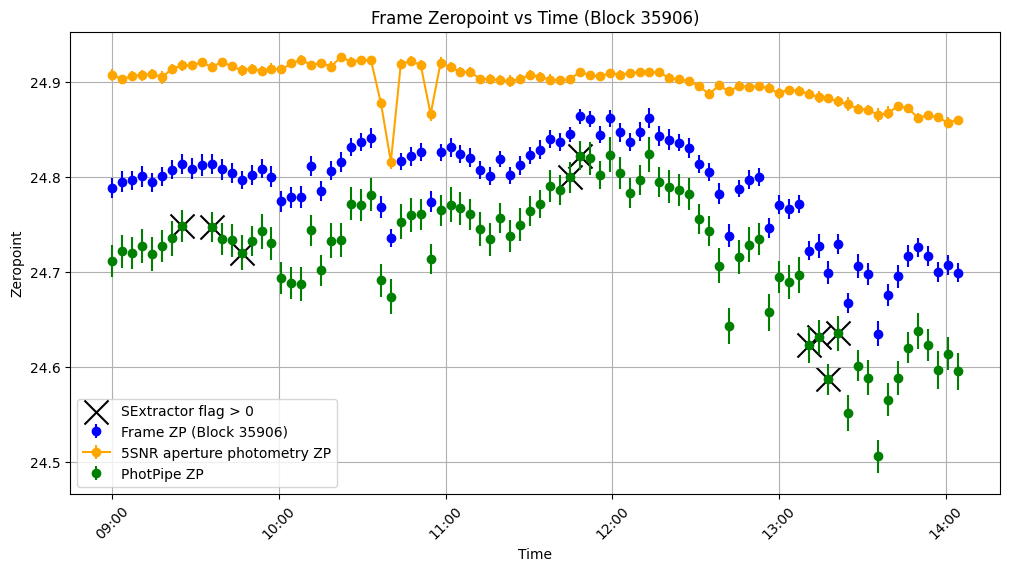

In [ ]:

#--------------------------------------------------------
#e-93 5 + SNR TABLE
#--------------------------------------------------------
table_5 = Table.read(filepath_ecsv_5, format="ascii.ecsv")
remap_frame_paths(table_5)


# Pipeline ZP time series (ecsv file already has info about the time column being a serialized astropy Time object, so we can just convert it to datetime)
times_5 = table_5["times"].datetime

ZP_5 = table_5["ZP"]
ZP_err_5 = table_5["ZP_sig"]

# --------------------------------------------------
# Get frame information from database
# --------------------------------------------------
frames_test = (
    Frame.objects.filter(
        block_id=35906,
        frametype=Frame.NEOX_RED_FRAMETYPE,
        filter='rp'
    )
    .order_by('midpoint')
    .values(
        'filename',
        'midpoint',
        'zeropoint',
        'zeropoint_err',
        'exptime'
    )
)

# Convert Django queryset -> Astropy table
db_t = Table(rows=list(frames_test))

# Convert database times
times = Time(db_t["midpoint"]).datetime


# --------------------------------------------------
# Read photometry pipeline table
# --------------------------------------------------
Phot_path = Path(
    didymos_data,
    "subtraction_analysis",
    "lcogt_coj-PP_ep07_20260712_4253588_65803didymos_photometry.tab"
)

Phot_pipe_table = Table.read(
    Phot_path,
    format="ascii"
)


# Rename the "file" column to match the database table and then join the two tables on filename
Phot_pipe_table.rename_column("file", "filename")
merged_table = join(Phot_pipe_table, db_t, keys="filename", join_type="inner")
merged_table.sort('julian_date')

# Pipeline times
julian_date = merged_table["julian_date"]
phot_times = Time(julian_date, format="jd").datetime

# Photometry Pipeline ZP
# Correct Source Extractor ZP for exposure time (which is per-exposure, not per-second)
ZP = merged_table["ZP"] - 2.5 * np.log10(merged_table["exptime"])
ZP_err = merged_table["ZP_sig"]
delta_ZP = ZP - merged_table["zeropoint"]
delta_ZP_err = np.hypot(ZP_err, merged_table["zeropoint_err"])

# SExtractor flags
bad_flag = merged_table["SExtractor_flag"]  > 0


# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))


# Raw Frame ZP
ax.errorbar(
    times,
    db_t["zeropoint"],
    yerr=db_t["zeropoint_err"],
    fmt='o',
    label="Frame ZP (Block 35906)",
    color = "blue"
)


#add e-93s
ax.errorbar(
    times_5,
    ZP_5,
    yerr=ZP_err_5,
    fmt='o-',
    color='orange',
    label="5SNR aperture photometry ZP"
)

# Photometry Pipeline ZP (green)
ax.errorbar(
    phot_times,
    ZP,
    yerr=ZP_err,
    fmt='o',
    color='green',
    label="PhotPipe ZP"
)


# Mark flagged pipeline files
ax.scatter(
    phot_times[bad_flag],
    ZP[bad_flag],
    marker='x',
    s=300,
    color='black',
    label="SExtractor flag > 0"
)


# Formatting
ax.set_xlabel("Time")
ax.set_ylabel("Zeropoint")
ax.set_title("Frame Zeropoint vs Time (Block 35906)")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.xticks(rotation=45)

ax.legend()
ax.grid(True)
# Do not invert y-axis for ZP, as higher ZP is better
# ax.invert_yaxis()
plt.show()

Median difference between PhotPipe ZP and database ZP: -0.069 mag


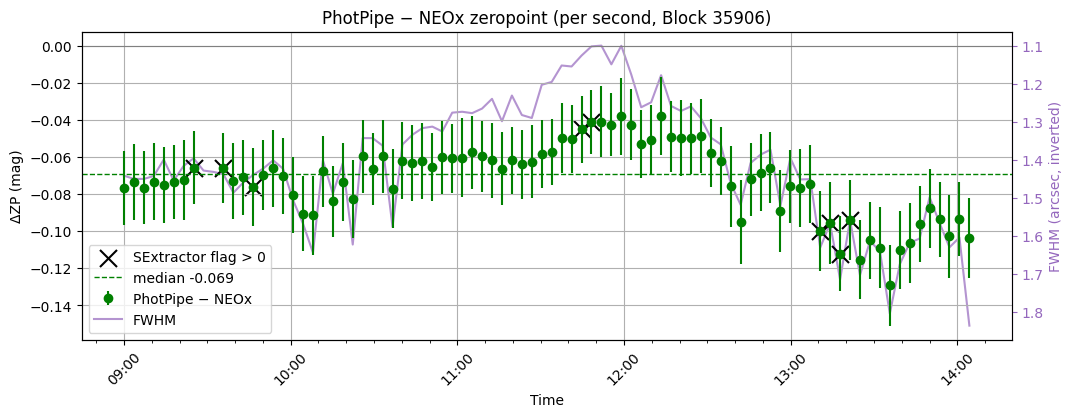

In [26]:
median_delta_ZP = np.median(delta_ZP)
print(f"Median difference between PhotPipe ZP and database ZP: {median_delta_ZP:.3f} mag")

fig2, ax2 = plt.subplots(figsize=(12, 4))

ax2.errorbar(phot_times, delta_ZP, yerr=delta_ZP_err, fmt='o', color='green', label="PhotPipe − NEOx")
ax2.scatter(phot_times[bad_flag], delta_ZP[bad_flag], marker='x', s=150, color='black', label="SExtractor flag > 0")
ax2.axhline(0, color='grey', lw=0.8)
ax2.axhline(median_delta_ZP, color='green', ls='--', lw=1, label=f"median {median_delta_ZP:+.3f}")

# FWHM on a second y-axis, inverted so it tracks ΔZP (they are anti-correlated)
fwhm_color = 'tab:purple'
ax2b = ax2.twinx()
# Original version, needs a modification above to fetch the FWHM from the database table
# ax2b.plot(phot_times, merged_table['fwhm'], '-', color=fwhm_color, lw=1.5, alpha=0.7, label="FWHM")
ax2b.plot(times_5, table_5['FWHM'], '-', color=fwhm_color, lw=1.5, alpha=0.7, label="FWHM")
ax2b.set_ylabel("FWHM (arcsec, inverted)", color=fwhm_color)
ax2b.tick_params(axis='y', colors=fwhm_color)
ax2b.spines['right'].set_color(fwhm_color)
ax2b.invert_yaxis()

# Draw the ΔZP points above the FWHM line; twinx() otherwise stacks the new axis on top
ax2.set_zorder(ax2b.get_zorder() + 1)
ax2.patch.set_visible(False)

ax2.set_xlim(ax.get_xlim())
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax2.tick_params(axis='x', labelrotation=45)
ax2.xaxis.set_minor_locator(mdates.MinuteLocator(byminute=range(0, 60, 10)))
ax2.set_xlabel("Time")
ax2.set_ylabel("ΔZP (mag)")
ax2.set_title("PhotPipe − NEOx zeropoint (per second, Block 35906)")

h1, l1 = ax2.get_legend_handles_labels()
h2, l2 = ax2b.get_legend_handles_labels()
ax2.legend(h1 + h2, l1 + l2, loc='best')
ax2.grid(True)
plt.show()

## Source Extractor Flagging

In [36]:
###--- SEXTRACTOR FLAGGING ---###
flag = Phot_pipe_table['SExtractor_flag']


# 3 --ap phot biased by neighboring sources + object is deblended
#2 --deblended

unique, counts, index = np.unique(flag, return_counts=True, return_index=True)

for uc, c, i in zip(unique,counts,index):
    print("---------------------------")
    print(f"index{i}: flag{uc} {c} frames")

mask_flag = flag > 0

phot_pipe_t_flag = Phot_pipe_table[mask_flag]

for row in phot_pipe_t_flag:
    print("--------------------------")
    print(f"{row['file']}, {row['SExtractor_flag']}")





---------------------------
index75: flag0 0 frames
---------------------------
index3: flag2 11 frames
---------------------------
index6: flag3 7 frames
--------------------------
coj2m002-ep07-20260712-0065-e92.fits, 3
--------------------------
coj2m002-ep07-20260712-0068-e92.fits, 3
--------------------------
coj2m002-ep07-20260712-0071-e92.fits, 2
--------------------------
coj2m002-ep07-20260712-0104-e92.fits, 2
--------------------------
coj2m002-ep07-20260712-0105-e92.fits, 2
--------------------------
coj2m002-ep07-20260712-0128-e92.fits, 3
--------------------------
coj2m002-ep07-20260712-0129-e92.fits, 3
--------------------------
coj2m002-ep07-20260712-0130-e92.fits, 3
--------------------------
coj2m002-ep07-20260712-0131-e92.fits, 3


## Examining Bad Subtractions

Changed badness Threshold for `examine_subtraction`

In [40]:

###use this to make heat map plots of flux values of the fits that we can open with ds9###
from django.db import close_old_connections

close_old_connections()
obs_block_bad = Block.objects.get(id =bad_blocks[0])
data_storage_filename_500, badness_storage_filename_500, bad_filenames_500, percent_bad_files_500 = examine_subtractions(
                                    obs_block_bad,
                                    sub_save_path,
                                    overwrite = True,
                                    badness_threshold = 400
 )

try:
    for f in bad_filenames_500:
        print(f"detected bad frame: {f}")
except IndexError as exc:
    raise IndexError("No files found") from exc

print(f"percent of bad files: {percent_bad_files_500}")

detected bad frame: coj2m002-ep07-20260712-0058-e93.fits
detected bad frame: coj2m002-ep07-20260712-0059-e93.fits
detected bad frame: coj2m002-ep07-20260712-0060-e93.fits
detected bad frame: coj2m002-ep07-20260712-0061-e93.fits
detected bad frame: coj2m002-ep07-20260712-0063-e93.fits
detected bad frame: coj2m002-ep07-20260712-0064-e93.fits
detected bad frame: coj2m002-ep07-20260712-0071-e93.fits
detected bad frame: coj2m002-ep07-20260712-0075-e93.fits
detected bad frame: coj2m002-ep07-20260712-0076-e93.fits
detected bad frame: coj2m002-ep07-20260712-0079-e93.fits
detected bad frame: coj2m002-ep07-20260712-0080-e93.fits
detected bad frame: coj2m002-ep07-20260712-0086-e93.fits
detected bad frame: coj2m002-ep07-20260712-0089-e93.fits
detected bad frame: coj2m002-ep07-20260712-0090-e93.fits
detected bad frame: coj2m002-ep07-20260712-0128-e93.fits
detected bad frame: coj2m002-ep07-20260712-0130-e93.fits
detected bad frame: coj2m002-ep07-20260712-0133-e93.fits
detected bad frame: coj2m002-ep

In [38]:
def bad_sub_highlighter(e93_bad_file_loc, base_dir_e93):
    """
    Objective: Locate poorly subtracted files, get the sum counts of the 9 boxes, 
    create rectangles of negative boxes that are 3x more negative thant the median box.

    Inputs:
    e93_file_loc (string): Has file path Table generated from `examine_subtractions` method
    base_dir_e93 (string): where ALL e93's are located

    Returns:
    Rectangle (matplotlib.patches.Rectangle): as in ax.add_patch(rect)

    """
    
    examine_subtractions_table = Table.read(e93_bad_file_loc, format = "ascii.ecsv")

    #Retreve  bad files
    bad_filenames =  examine_subtractions_table["filename"][
        examine_subtractions_table["bad_subtraction"] == True]

    bad_table = examine_subtractions_table[examine_subtractions_table["bad_subtraction"] == True]

    files = [os.path.join(base_dir_e93,f) for f in bad_filenames]

    #For each file, apply column mask for mean < 0 & std mask > 5
    mean_columns = [c for c in examine_subtractions_table.columns if c.strip(" ").split("_")[0] == "mean"]
    std_columns = [c for c in examine_subtractions_table.columns if c.strip(" ").split("_")[0] == "std"]

    #select boxes that are bad
    # only use already-selected bad subtraction files
    # store results
    bad_boxes_data = []

    for row in bad_table:

        for mean_col, std_col in zip(mean_columns, std_columns):

            if (row[mean_col] < -100) and (row[std_col] > 34.5): #VERY neg + STD
                fragment = mean_col.split("_")[1:3]
                x_col = f"x_cen_{fragment[0]}_{fragment[1]}"
                y_col = f"y_cen_{fragment[0]}_{fragment[1]}"
                bad_boxes_data.append(
                    (
                        row["filename"],
                        mean_col.replace("mean_", ""),
                        row[mean_col],
                        row[std_col],
                        row[x_col],
                        row[y_col]
                    )
                )

    # create Astropy table
    bad_boxes_table = Table(
        rows=bad_boxes_data,
        names=["filename", "box", "mean", "std", "xcen", "ycen"]
    )
    
    # Plot the xcen, yceb and a box around it 

    n = len(files)

    #make roughly square grid
    ncols = math.ceil(np.sqrt(n))
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(
         nrows,
         ncols,
         figsize=(4.5*ncols, 4.5*nrows),
         squeeze=False
     )
    fig.suptitle(
        "Files with Badness Threshold > 400 and Pixel Value < -100",
        fontsize = 28,
        y = 0.95 ) #title above axis)

    axes = axes.flatten()

    for ax, filename in zip(axes, files):

        with fits.open(filename) as hdul:
            data = hdul[0].data

            #get length and width ofa box 1/9 of image
            y , x = data.shape
            xwidth = x / 3
            ywidth = y /3
         # optional: improve contrast
        vmin, vmax = np.nanpercentile(data, [1, 99])

        im = ax.imshow(
             data,
             origin="lower",
             cmap="Greys",
             vmin=vmin,
             vmax=vmax
         )

        rows = bad_boxes_table[bad_boxes_table["filename"] == filename.split('/')[-1]] #select all rows associaed with fits
        for row in rows:
            xcen = row["xcen"]
            ycen = row["ycen"]

            #draw rectangle
            rect = Rectangle((xcen - xwidth/2, ycen - ywidth/2),
                             xwidth,
                             ywidth,
                             fill = False,
                             edgecolor = "red",
                             linewidth = 2
                             )
            ax.add_patch(rect)
            file_name = filename.split("/")[-1]

        ax.set_title(f"Frame: {file_name.split('-')[3]}", fontsize=12)

     # remove unused panels
    for ax in axes[len(files):]:
         ax.axis("off")

     # colorbar on far right
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])

    fig.colorbar(
         im,
         cax=cbar_ax,
         label="Flux"
     )

    #plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.show()

    return bad_boxes_table



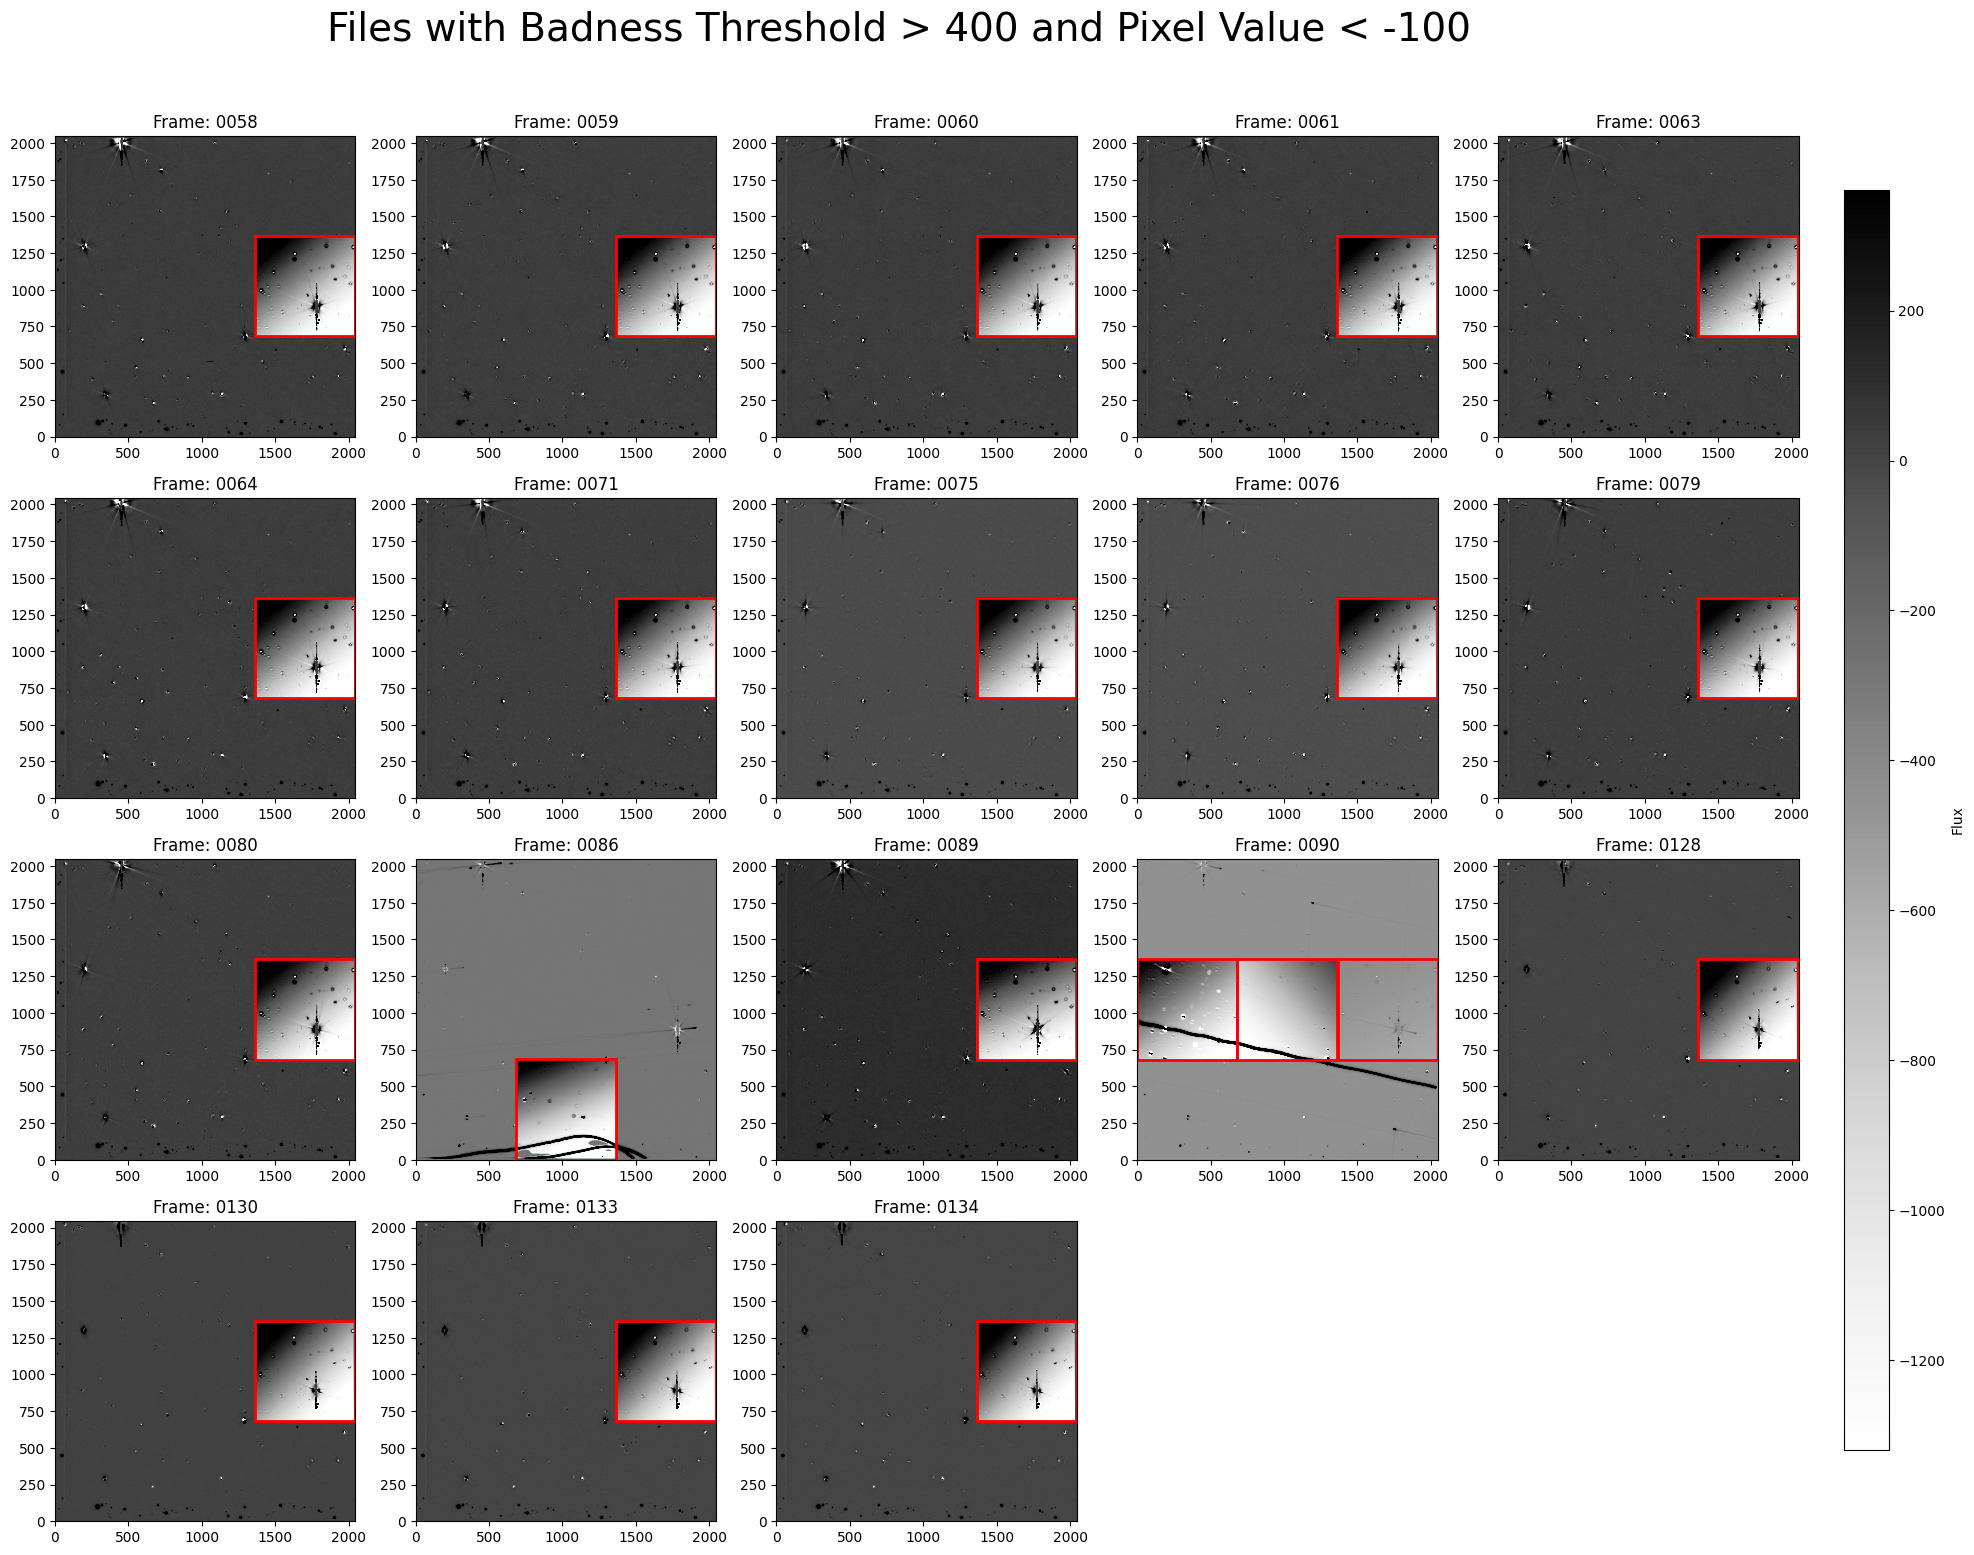

In [41]:
p = os.path.join(didymos_data, "subtraction_analysis", "examined_subtractions_table_2026-07-12.ecsv")
t = bad_filenames_500
b = os.path.join(didymos_data, "f06_012_e93")
bad_t_filt = bad_sub_highlighter(p,b)


In [42]:
print(bad_t_filt["mean"][17:24])

       mean       
------------------
-555.8209838867188
 -515.554931640625
-527.7075805664062


/tmp/ipykernel_1702608/855650717.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


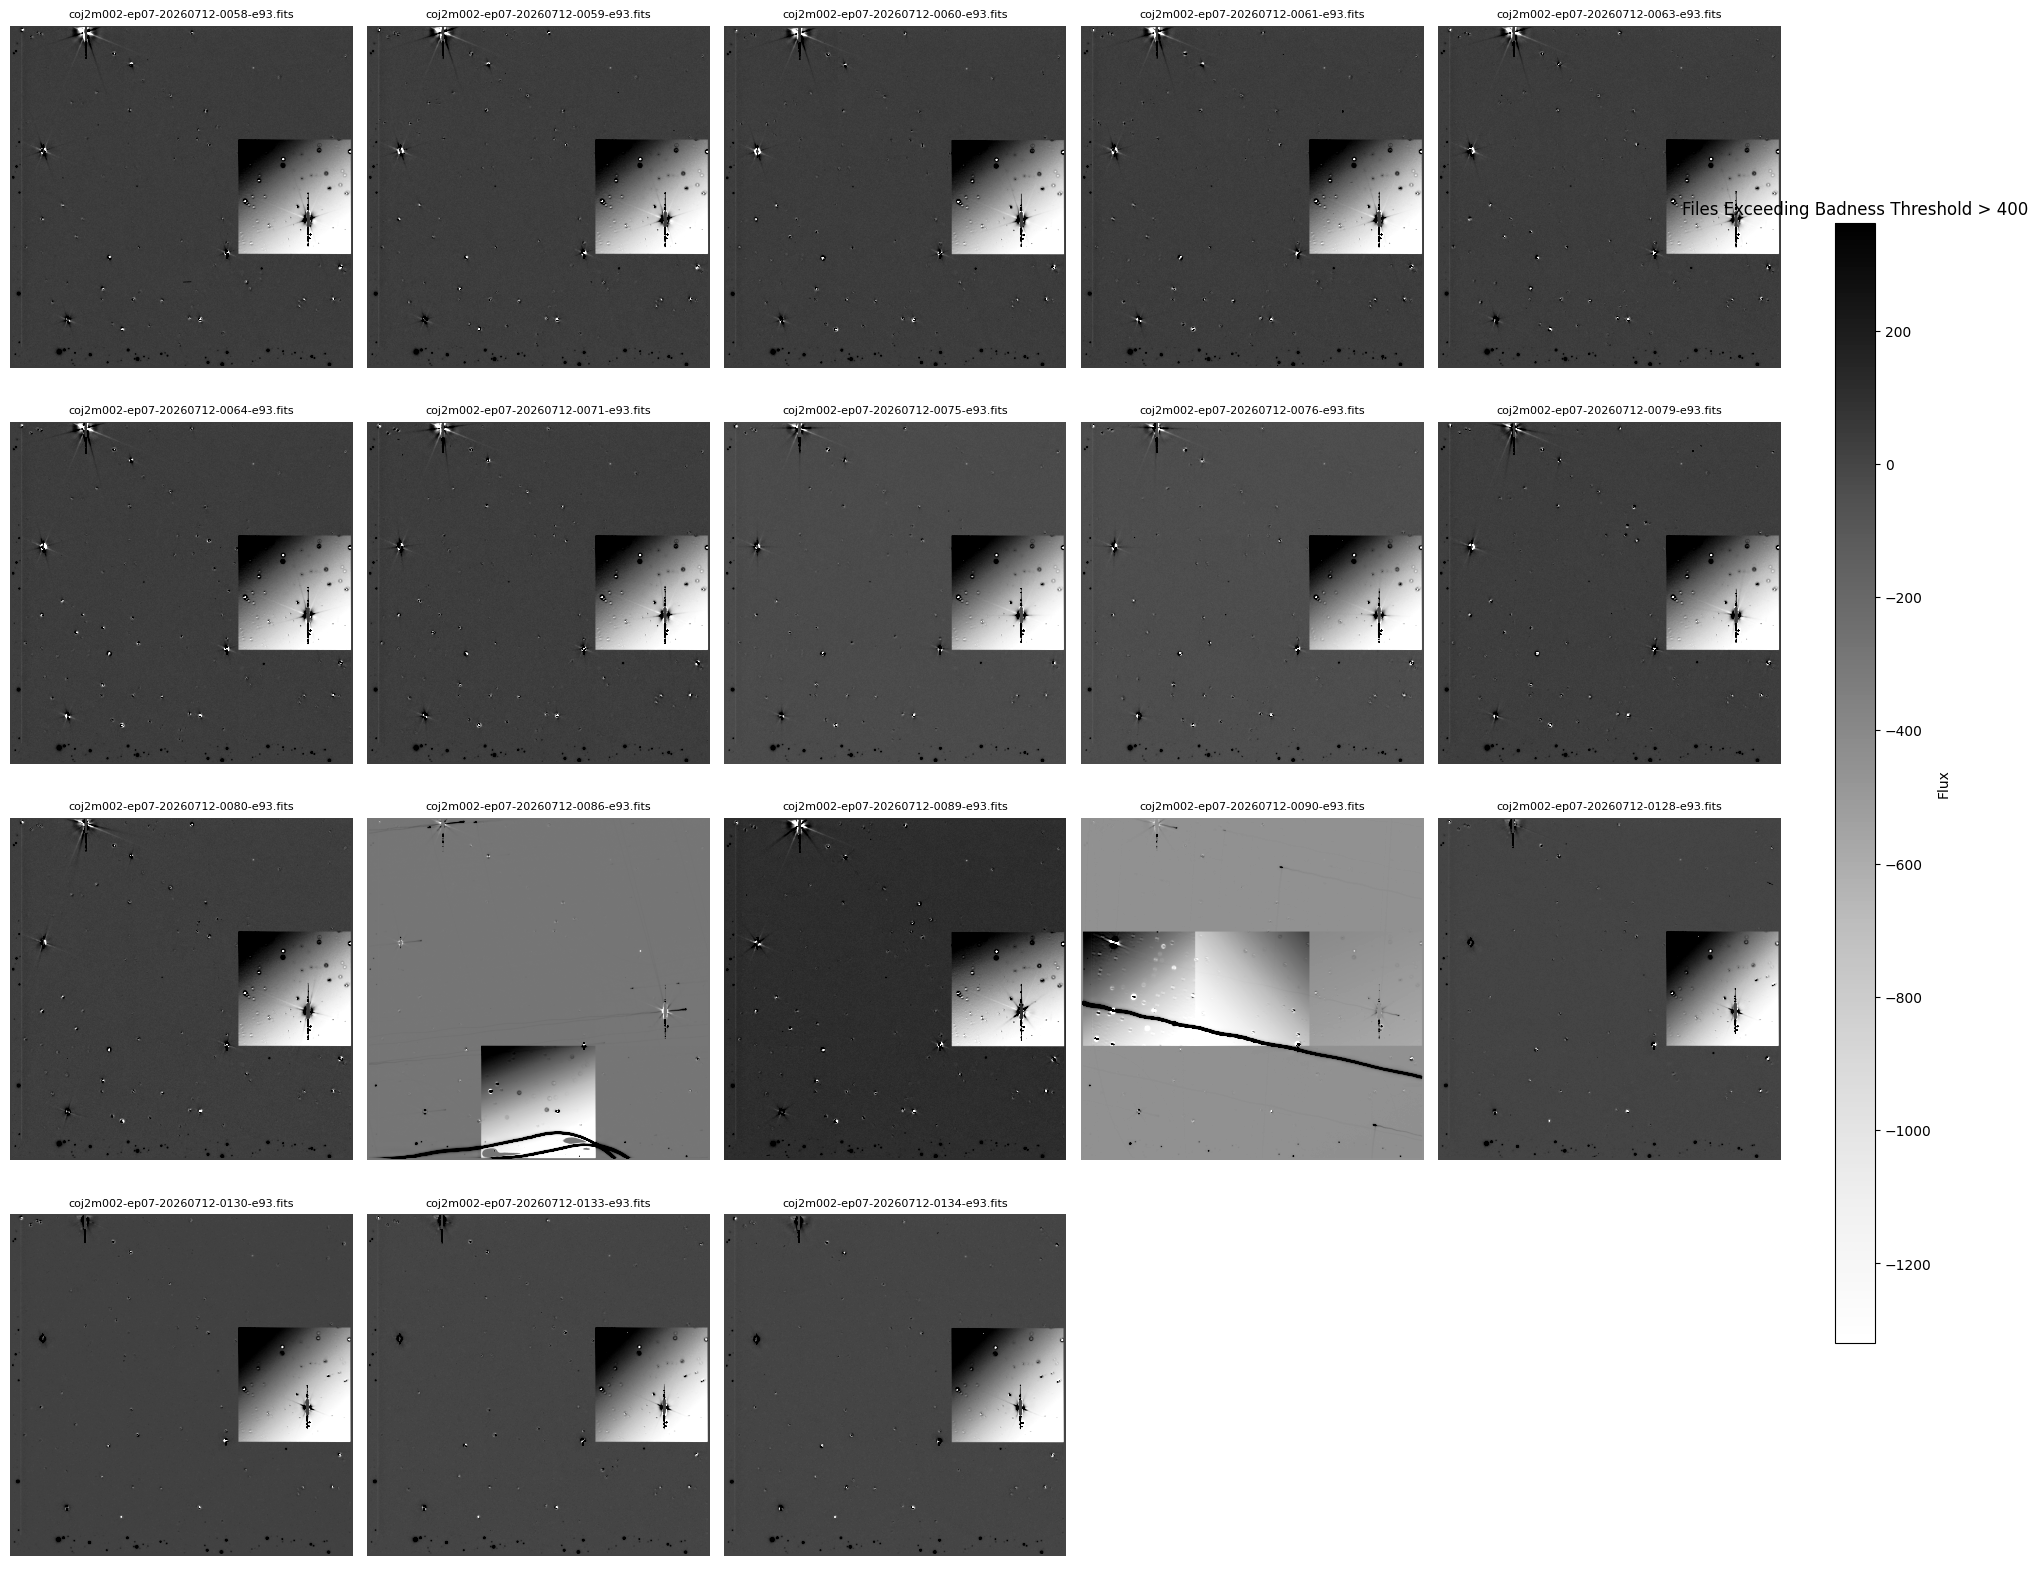

In [43]:
# list of bad subtraction FITS files

data_path = os.path.join(didymos_data, "f06_012_e93")
files = [os.path.join(data_path, f) for f in bad_filenames_500]

n = len(files)

# make roughly square grid
ncols = math.ceil(np.sqrt(n))
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(4*ncols, 4*nrows),
    squeeze=False
)

axes = axes.flatten()

for ax, filename in zip(axes, files):

    with fits.open(filename) as hdul:
        data = hdul[0].data

    # optional: improve contrast
    vmin, vmax = np.nanpercentile(data, [1, 99])

    im = ax.imshow(
        data,
        origin="lower",
        cmap="Greys",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(filename.split("/")[-1], fontsize=8)
    ax.axis("off")

# remove unused panels
for ax in axes[len(files):]:
    ax.axis("off")

# colorbar on far right
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])

fig.colorbar(
    im,
    cax=cbar_ax,
    label="Flux"
)

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.title("Files Exceeding Badness Threshold > 400")
plt.show()